In [1]:
import tensorflow as tf
print(tf.reduce_sum(tf.random.normal([1000, 1000])))
print(tf.config.list_physical_devices('GPU'))


2022-11-04 19:29:56.227428: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


tf.Tensor(593.7657, shape=(), dtype=float32)
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


2022-11-04 19:29:56.228436: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-04 19:29:56.535605: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-04 19:29:56.536561: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-04 19:29:56.537483: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-04 19:29:56.538515: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from S

In [2]:

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import csv 

import keras
import tensorflow as tf
from keras import backend
from keras.backend import set_session

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Dropout, LeakyReLU, Conv2DTranspose, ReLU
from tensorflow.keras.optimizers import Adam
from keras.layers import Reshape
from keras import layers
import datetime

from keras import initializers


config = tf.compat.v1.ConfigProto()
config.gpu_options.per_process_gpu_memory_fraction = 0.9 # fraction of memory
config.gpu_options.visible_device_list = "0"

set_session(tf.compat.v1.Session(config=config))

2022-11-04 19:30:02.926709: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-04 19:30:02.927834: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-04 19:30:02.928586: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-04 19:30:02.929363: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-04 19:30:02.930016: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from S

In [4]:
path = '../input/occlude-face-image'
xname = '1_half_face_occluded.pickle'
yname = '1_half_face_labels.pickle'
pickle_in = open(os.path.join(path,xname),"rb")
x = pickle.load(pickle_in)

pickle_in = open(os.path.join(path,yname),"rb")
y = pickle.load(pickle_in)

print(x.shape)
print(y.shape)

(4471, 200, 200, 1)
(4471, 200, 200, 1)


In [5]:
fields = ["Gan Loss", "Disc loss", "Gen Loss" , "Test Gan Loss", "Test Disc Loss"]
rows = []
print(rows)

[]


(4471, 64, 64, 1)
(4471, 64, 64, 1)


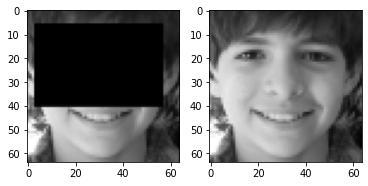

In [6]:
#I use this because with 200,200 images, I exceed GPU memory.

from skimage.transform import resize
x = resize(x, (len(x),64,64,1), anti_aliasing=False)
y = resize(y, (len(y),64,64,1), anti_aliasing=False)

# Print the shape after resize
print(x.shape)
print(y.shape)

#Draw the image to be sure occluded image is the same as the ground truth one
fig=plt.figure(figsize=(6, 6))
fig.add_subplot(1, 2, 1)
plt.imshow(x[3,:,:,0],cmap="gray")
fig.add_subplot(1, 2, 2)
plt.imshow(y[3,:,:,0],cmap="gray")

In [7]:
#I print pixel values to be sure occluded and ground truth images are aligned
print(x[0,0:5,0:5,0])
print(y[0,0:5,0:5,0])

[[0.25130208 0.304856   0.30303309 0.34253983 0.3629136 ]
 [0.27388174 0.32608762 0.34776348 0.36331189 0.38823529]
 [0.23821998 0.30718444 0.32617953 0.38941483 0.38988971]
 [0.27643995 0.32598039 0.35706189 0.36937806 0.41199449]
 [0.2950674  0.32501532 0.3527114  0.38802083 0.40833333]]
[[0.25130208 0.304856   0.30303309 0.34253983 0.3629136 ]
 [0.27388174 0.32608762 0.34776348 0.36331189 0.38823529]
 [0.23821998 0.30718444 0.32617953 0.38941483 0.38988971]
 [0.27643995 0.32598039 0.35706189 0.36937806 0.41199449]
 [0.2950674  0.32501532 0.3527114  0.38802083 0.40833333]]


In [8]:
#Here is the function to create a generator. I also use the function and create a generator in the same cell.
def creategen():
  generator = Sequential()


  generator.add(Conv2D(64, (5,5) , strides = (2,2), input_shape = x.shape[1:] , padding = "SAME",kernel_initializer = 'random_normal'))
  generator.add(BatchNormalization())
  generator.add(ReLU())  
  generator.add(Dropout(0.3))


  generator.add(Conv2D(128, (5,5) ,  strides = (2,2),padding = "SAME",kernel_initializer = 'random_normal'))
  generator.add(BatchNormalization())
  generator.add(ReLU())  
  generator.add(Dropout(0.3))

  
  generator.add(Conv2D(256, (5,5) ,  strides = (2,2), padding = "SAME",kernel_initializer = 'random_normal'))
  generator.add(BatchNormalization())
  generator.add(ReLU())  
  generator.add(Dropout(0.3))

  # I would use these if there was a bottleneck in the network.
  #generator.add(Flatten())
  
  #generator.add(Dense(64)) 
  #generator.add(BatchNormalization())
  #generator.add(ReLU(alpha=0.2))
  
  #generator.add(Dense(8*8*128)) 
  #generator.add(BatchNormalization())
  #generator.add(ReLU(alpha=0.2))
  
  #generator.add(layers.Reshape((8,8,128)))


  generator.add(Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
  generator.add(BatchNormalization())
  generator.add(ReLU())
  
  generator.add(Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
  generator.add(BatchNormalization())
  generator.add(ReLU())
  
  generator.add(Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation = "tanh"))
  

  return generator

generator = creategen()



In [9]:
#Here is the function to create a discriminator. 
#I also use the function and create a discriminator in the same cell.
def createdisc():
  discriminator = Sequential()

  discriminator.add(Conv2D(64, (5,5) , strides = (2,2), input_shape = x.shape[1:] , padding = "SAME",kernel_initializer = 'random_normal'))
  discriminator.add(BatchNormalization())
  discriminator.add(LeakyReLU(alpha=0.2))  
  discriminator.add(Dropout(0.3))


  discriminator.add(Conv2D(128, (5,5) ,  strides = (2,2),padding = "SAME",kernel_initializer = 'random_normal'))
  discriminator.add(BatchNormalization())
  discriminator.add(LeakyReLU(alpha=0.2))  
  discriminator.add(Dropout(0.3))

  
  discriminator.add(Conv2D(256, (5,5) ,  strides = (2,2), padding = "SAME",kernel_initializer = 'random_normal'))
  discriminator.add(BatchNormalization())
  discriminator.add(LeakyReLU(alpha=0.2))  
  discriminator.add(Dropout(0.3))

  
  discriminator.add(Flatten())
  discriminator.add(Dense(1))
  
  return discriminator


discriminator = createdisc()



In [10]:
generator.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 32, 32, 64)        1664      
_________________________________________________________________
batch_normalization (BatchNo (None, 32, 32, 64)        256       
_________________________________________________________________
re_lu (ReLU)                 (None, 32, 32, 64)        0         
_________________________________________________________________
dropout (Dropout)            (None, 32, 32, 64)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 16, 16, 128)       204928    
_________________________________________________________________
batch_normalization_1 (Batch (None, 16, 16, 128)       512       
_________________________________________________________________
re_lu_1 (ReLU)               (None, 16, 16, 128)       0

In [11]:
# Learning rate of discriminator is advised to be the double of the generator. 
# I train the generator two times in each step of training. First is with Gan loss, second is with L2 loss.
# That is why I use x4 learning rate in discriminator.

opt_disc = Adam(lr=0.00004)
discriminator.trainable = True
discriminator.compile(loss = "binary_crossentropy", optimizer = opt_disc)
discriminator.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_3 (Conv2D)            (None, 32, 32, 64)        1664      
_________________________________________________________________
batch_normalization_5 (Batch (None, 32, 32, 64)        256       
_________________________________________________________________
leaky_re_lu (LeakyReLU)      (None, 32, 32, 64)        0         
_________________________________________________________________
dropout_3 (Dropout)          (None, 32, 32, 64)        0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 16, 16, 128)       204928    
_________________________________________________________________
batch_normalization_6 (Batch (None, 16, 16, 128)       512       
_________________________________________________________________
leaky_re_lu_1 (LeakyReLU)    (None, 16, 16, 128)      

/opt/conda/lib/python3.7/site-packages/keras/optimizer_v2/optimizer_v2.py:356: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  "The `lr` argument is deprecated, use `learning_rate` instead.")


In [12]:
opt_gen = Adam(lr=0.00001)
generator.compile(loss='mean_squared_error', optimizer = opt_gen)
generator.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 32, 32, 64)        1664      
_________________________________________________________________
batch_normalization (BatchNo (None, 32, 32, 64)        256       
_________________________________________________________________
re_lu (ReLU)                 (None, 32, 32, 64)        0         
_________________________________________________________________
dropout (Dropout)            (None, 32, 32, 64)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 16, 16, 128)       204928    
_________________________________________________________________
batch_normalization_1 (Batch (None, 16, 16, 128)       512       
_________________________________________________________________
re_lu_1 (ReLU)               (None, 16, 16, 128)       0

In [13]:
#Here is the function to create a GAN model. I also use the function and create GAN model in the same cell.

def creategan(generator,discriminator):
  gan = Sequential()
  gan.add(generator)
  discriminator.trainable = False
  gan.add(discriminator)
  return(gan)

gan = creategan(generator,discriminator)

In [14]:
opt_gan = Adam(lr=0.00001)
gan.compile(loss = "binary_crossentropy", optimizer = opt_gan)
gan.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequential (Sequential)      (None, 64, 64, 1)         2054208   
_________________________________________________________________
sequential_1 (Sequential)    (None, 1)                 1044225   
Total params: 3,098,433
Trainable params: 2,052,928
Non-trainable params: 1,045,505
_________________________________________________________________


In [15]:
# This is to save models. It saves both the architectures and the weights.
# While loading the model, you will only need weights since you declared the architecture in the previous cells.

def save_models(gan,discriminator,generator,path,epoch):
  datenow = str(datetime.datetime.now().strftime('%m-%d-%H:%M'))
  gan.save_weights(os.path.join(path,"{0}_wgan_{1}.h5".format(epoch,datenow)))
  gan.save(os.path.join(path,"{0}_mgan_{1}.h5".format(epoch,datenow)))


  discriminator.save_weights(os.path.join(path,"{0}_wd_{1}.h5".format(epoch,datenow)))
  discriminator.save(os.path.join(path,"{0}_md_{1}.h5".format(epoch,datenow)))


  generator.save_weights(os.path.join(path,"{0}_wg_{1}.h5".format(epoch,datenow)))
  generator.save(os.path.join(path,"{0}_mg_{1}.h5".format(epoch,datenow)))
  

  

In [16]:
def test(x,y):
  gan_inp_t = x  
  gan_label_t = np.ones([len(gan_inp_t)])
  gan_predict_t = None
  
  disc_inp_t = None


  disc_label_t = np.zeros([len(gan_inp_t)*2])
  disc_label_t[len(gan_inp_t):] = 1
  
  disc_predict_t = None
  

  gen_predict_t = generator.predict(gan_inp_t)


  disc_inp_t = np.concatenate((gen_predict_t,y), axis = 0)
  disc_predict_t = discriminator.predict(disc_inp_t)

  d_loss_t = discriminator.test_on_batch(disc_inp_t,disc_label_t)

  gan_loss_t = gan.test_on_batch(gan_inp_t,gan_label_t)
  
  return (gan_loss_t, d_loss_t)

In [17]:
# In the previous versions, I used this function to pretrain the discriminator in each training step.
# I do not use this function in this version.
def pretrain(x,y,nepoch):
    
  gen_predict = None
  
  
  gan_inp = x  
  gan_label = np.ones(64)
  gan_predict = None
  
  disc_inp = None


  disc_label = np.zeros(64*2)
  disc_label[64:] = 1
  
  disc_predict = None
  
  
  for epoch in range(nepoch):
    for batch_ctr in range(65):


      gen_predict = generator.predict(gan_inp[batch_ctr*64:(batch_ctr+1)*64])


      disc_inp = np.concatenate((gen_predict,y[batch_ctr*64:(batch_ctr+1)*64]), axis = 0)
      disc_predict = discriminator.predict(disc_inp)



      d_loss = discriminator.train_on_batch(disc_inp,disc_label)


      gan_loss = gan.test_on_batch(gan_inp[batch_ctr*64:(batch_ctr+1)*64],
                                    gan_label)
    

    (tgan,tdisc)= test(x[4160:],y[4160:])
    print("Pretrain Epoch Gan Loss: {0}       Disc Loss: {1}".format(gan_loss,d_loss))
    print("Pretrain Epoch Test Gan Loss: {0}  Test Disc Loss: {1} \n\n\n".format(tgan,tdisc))

In [18]:
# I use isolated mini batches to slow down discriminator:
# I also use smooth/noisy labels proposed by Salimans et al 2016
# Reference: https://github.com/soumith/ganhacks



def train(x,y, nepoch, model_save_path = "./"):

  gen_predict = None
  
  #Initialize the inputs and the labels.
  gan_inp = x  
  gan_label = np.ones(64)
  gan_predict = None
  
  disc_inp = None


  disc_label = np.zeros(64*2)
  disc_label[64:] = 1
  
  disc_predict = None
  

  sess = tf.compat.v1.Session()

  

  for epoch in range(nepoch):

    for batch_ctr in range(65):

      #Generator makes a prediction.
      gen_predict = generator.predict(gan_inp[batch_ctr*64:(batch_ctr+1)*64])


      #Minibatch isolation and label smoothing is done here:
      
      if(epoch%2==0):
        disc_inp = gen_predict
        #disc_label = np.zeros(64) //// I would use this line if there was no noisy labels.
        disc_label = np.random.normal(loc=0, scale=0.10, size=64)
      else:
        disc_inp = y[batch_ctr*64:(batch_ctr+1)*64]
        #disc_label = np.ones(64)  //// I would use this line if there was no noisy labels.
        disc_label = np.random.normal(loc=1, scale=0.10, size=64)


        
      #Initialize a label variable for generator to use it in training.  
      gen_label = y[batch_ctr*64:(batch_ctr+1)*64]
      
      
      #Do one training step. Also assign the losses to variables. We will print them.
      d_loss = discriminator.train_on_batch(disc_inp,disc_label)


      gan_loss = gan.train_on_batch(gan_inp[batch_ctr*64:(batch_ctr+1)*64],
                                    gan_label)

      gen_loss = generator.train_on_batch(gan_inp[batch_ctr*64:(batch_ctr+1)*64],gen_label)
      
    
    
    if epoch == nepoch - 1:
      save_models(gan,discriminator,generator, model_save_path,epoch+1)  
      print("MODEL SAVED")
      
    
    # Test images are the images after the 4160th image. It makes 311 test images.
    (tgan,tdisc)= test(x[4160:],y[4160:])
    
    rows.append([gan_loss,d_loss,gen_loss,tgan,tdisc])
    print("Epoch: {2} Gan Loss: {0}       Disc Loss: {1}        Gen Loss: {3}".format(gan_loss,d_loss,epoch+1,gen_loss))
    print("Epoch: {2} Test Gan Loss: {0}  Test Disc Loss: {1} \n\n\n".format(tgan,tdisc,epoch+1))

In [19]:
# Checking lengths of the input and ground truth arrays. Also checking if normalization is done.
print(len(x),len(y))
print(x.max(),x.min())
print(y.max(),y.min())

4471 4471
1.0 0.0
1.0 0.0


In [20]:
# Use this cell if you have loaded and viewed the results, and want to train further.
# If you start the model from beginning, using above cells where I declare 
# generator architecture, discriminator architecture etc. , you don't need to use this cell since
# I already compile the models in above cells.


# Learning rate of discriminator is advised to be the double of the generator. 
# I train the generator two times in each step of training. First is with Gan loss, second is with L2 loss.
# That is why I use x4 learning rate in discriminator.

"""opt_disc = Adam(lr=0.00004)
discriminator.trainable = True
discriminator.compile(loss = "binary_crossentropy", optimizer = opt_disc)
discriminator.summary()

opt_gen = Adam(lr=0.00001)
generator.compile(loss='mean_squared_error', optimizer = opt_gen)
generator.summary()

opt_gan = Adam(lr=0.00001)
gan.compile(loss = "binary_crossentropy", optimizer = opt_gan)
gan.summary()"""

'opt_disc = Adam(lr=0.00004)\ndiscriminator.trainable = True\ndiscriminator.compile(loss = "binary_crossentropy", optimizer = opt_disc)\ndiscriminator.summary()\n\nopt_gen = Adam(lr=0.00001)\ngenerator.compile(loss=\'mean_squared_error\', optimizer = opt_gen)\ngenerator.summary()\n\nopt_gan = Adam(lr=0.00001)\ngan.compile(loss = "binary_crossentropy", optimizer = opt_gan)\ngan.summary()'

In [21]:
# To train, don't forget to:
# -compile the models
# - run the necessary cells to declare the necessary functions such as "train" and "save_models" and "test"

#If you train models from beginning, just run the cells of the notebook in order.

#If you want to further train loaded models, use the previous cell to compile models.

model_save_path = './'
batch_size = 64
train(x,y,1500,model_save_path)


2022-11-04 19:30:17.230841: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-04 19:30:17.232188: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-04 19:30:17.233345: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-04 19:30:17.234046: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-04 19:30:17.235133: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from S

Epoch: 1 Gan Loss: 15.424948692321777       Disc Loss: -0.08150097727775574        Gen Loss: 0.3961315155029297
Epoch: 1 Test Gan Loss: 15.424947738647461  Test Disc Loss: 7.7124738693237305 



Epoch: 2 Gan Loss: 1.7375173568725586       Disc Loss: 0.31385383009910583        Gen Loss: 0.2484743744134903
Epoch: 2 Test Gan Loss: 0.7519271373748779  Test Disc Loss: 0.34567543864250183 



Epoch: 3 Gan Loss: 13.880655288696289       Disc Loss: -0.09168260544538498        Gen Loss: 0.1785617172718048
Epoch: 3 Test Gan Loss: 15.250041961669922  Test Disc Loss: 2.321401596069336 



Epoch: 4 Gan Loss: 13.219511985778809       Disc Loss: -0.20023174583911896        Gen Loss: 0.13577628135681152
Epoch: 4 Test Gan Loss: 14.426959037780762  Test Disc Loss: 0.20109356939792633 



Epoch: 5 Gan Loss: 15.424948692321777       Disc Loss: 0.025600090622901917        Gen Loss: 0.10836121439933777
Epoch: 5 Test Gan Loss: 15.424947738647461  Test Disc Loss: 2.22318959236145 



Epoch: 6 Gan Loss: 13.535

2022-11-04 22:09:01.088706: W tensorflow/core/data/root_dataset.cc:167] Optimization loop failed: Cancelled: Operation was cancelled


Epoch: 852 Gan Loss: 0.0       Disc Loss: -0.09830184280872345        Gen Loss: 0.005197419319301844
Epoch: 852 Test Gan Loss: 0.7074334025382996  Test Disc Loss: 6.985727787017822 



Epoch: 853 Gan Loss: 13.347496032714844       Disc Loss: -0.16508539021015167        Gen Loss: 0.005150024779140949
Epoch: 853 Test Gan Loss: 15.375349998474121  Test Disc Loss: 1.9886723756790161 



Epoch: 854 Gan Loss: 7.217118263244629       Disc Loss: 0.04005890712141991        Gen Loss: 0.005191551521420479
Epoch: 854 Test Gan Loss: 14.696213722229004  Test Disc Loss: 1.075028419494629 



Epoch: 855 Gan Loss: 15.424948692321777       Disc Loss: 0.16109785437583923        Gen Loss: 0.005250256508588791
Epoch: 855 Test Gan Loss: 15.424947738647461  Test Disc Loss: 3.5912022590637207 



Epoch: 856 Gan Loss: 12.950129508972168       Disc Loss: 0.7052531242370605        Gen Loss: 0.0051184045150876045
Epoch: 856 Test Gan Loss: 15.375349998474121  Test Disc Loss: 1.4860522747039795 



Epoch: 857 Gan L

In [22]:
filename = "loss.csv"
    
# writing to csv file 
with open(filename, 'w', newline='') as csvfile: 
    # creating a csv writer object 
    csvwriter = csv.writer(csvfile) 
        
    # writing the fields 
    csvwriter.writerow(fields) 
        
    # writing the data rows 
    csvwriter.writerows(rows)

In [23]:
#print(os.path.join(model_path,"{0}_wg_11-04-11_28.h5".format(epoch)))

# model_path = "../input/weight-500"

# epoch = 1500

# #generator = creategen()
# generator.load_weights(os.path.join(model_path,"{0}_wg_11-04-19_04.h5".format(epoch)))
# #discriminator = createdisc()
# discriminator.load_weights(os.path.join(model_path,"{0}_wd_11-04-19_04.h5".format(epoch)))

# #gan = creategan(generator,discriminator)
# gan.load_weights(os.path.join(model_path,"{0}_wgan_11-04-19_04.h5".format(epoch)))

In [24]:
#Making predictions and drawing them.
#First row: Occluded images
#Second row: Ground Truth images
#Third row: Predictions

# import datetime
# plot_path = "./"

# a = 4160
# b = 4170
# pred=generator.predict(x[a:b])

# fig = plt.figure(figsize = (20,10))
# for ctr in range(10):
#   fig.add_subplot(3,10,ctr+1)
#   plt.imshow(np.reshape(x[a + ctr],(64,64)),  cmap = "gray")

  

# for ctr in range(10):
#   fig.add_subplot(3,10,(10 + ctr + 1))
#   plt.imshow(np.reshape(y[a + ctr]/255,(64,64)),  cmap = "gray")  


# for ctr in range(10):
#   fig.add_subplot(3,10,(20 + ctr + 1))
#   plt.imshow(np.reshape(pred[ctr],(64,64)),  cmap = "gray")
  
# plt.savefig(os.path.join(plot_path,str(datetime.datetime.now().strftime('%m-%d-%H:%M'))))